Technique	Objectif	Question

Correlation / EDA:	voir les liens simples	Est-ce que HR élevé va avec sleep score bas ?

Linear Regression:	prédire une valeur continue	Peut-on prédire le sleep score ?

Random Forest Regressor:	modèle non linéaire	Quelles variables influencent le plus le recovery ?

Logistic Regression:	classer les mauvais jours	Peut-on prédire “poor recovery day” ?

Decision Tree:	règles interprétables	À partir de quel HR/durée ça devient mauvais ?

K-Means clustering:	trouver des types de journées	Quels profils de journées existent ?

Isolation Forest:	détecter les jours anormaux	Quels jours sortent du pattern habituel ?

In [1]:
print("kernel ok")

kernel ok


In [1]:
import sys
print(sys.executable)

c:\Users\Utilisateur\Documents\GitHub\Healthy-Girly\.venv\Scripts\python.exe


In [2]:
import sklearn
print(sklearn.__version__)

1.8.0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

pd.set_option("display.max_columns", 150)

In [5]:
DATA_DIR = Path("./data")
MERGED_PATH = DATA_DIR / "processed" / "daily_health_merged.csv"

daily = pd.read_csv(MERGED_PATH)

daily["date"] = pd.to_datetime(daily["date"], errors="coerce")
daily = daily.sort_values("date").reset_index(drop=True)

print(daily.shape)
display(daily.head())
display(daily.tail())

(154, 36)


,date,body_battery_high,body_battery_low,body_battery_range,extraction_confidence,notes,resting_hr,high_hr,sleep_score,Quality,sleep_duration_min,sleep_duration_h,sleep_need_min,sleep_need_h,sleep_debt_h,Bedtime,Wake Time,avg_stress,rest_min,low_stress_min,medium_stress_min,high_stress_min,rest_h,low_stress_h,medium_stress_h,high_stress_h,activity_count,total_activity_duration_min,total_activity_distance_km,total_activity_calories,mean_activity_hr,max_activity_hr,max_aerobic_te,total_activity_steps,total_body_battery_drain_activity,total_activity_duration_h
0,1989-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,19007.200000,0.0,84.0,NaN,165.0,2.1,2.147485e+09,-2.0,316.786667
1,2025-12-24,23.0,8.0,15.0,high,NaN,88.0,105.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72.0,0.0,16.0,86.0,82.0,0.000000,0.266667,1.433333,1.366667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-12-25,42.0,6.0,36.0,high,NaN,68.0,125.0,74.0,Fair,480.0,8.000000,470.0,7.833333,-0.166667,1:41 AM,10:09 AM,34.0,451.0,549.0,142.0,35.0,7.516667,9.150000,2.366667,0.583333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-12-26,79.0,16.0,63.0,high,NaN,66.0,109.0,84.0,Good,455.0,7.583333,480.0,8.000000,0.416667,1:11 AM,9:00 AM,24.0,883.0,341.0,49.0,7.0,14.716667,5.683333,0.816667,0.116667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-12-27,68.0,18.0,50.0,high,NaN,68.0,139.0,75.0,Fair,426.0,7.100000,480.0,8.000000,0.900000,1:41 AM,9:11 AM,33.0,519.0,454.0,178.0,8.0,8.650000,7.566667,2.966667,0.133333,1.0,12.216667,0.0,0.0,83.0,92.0,0.0,8.000000e+00,0.0,0.203611


,date,body_battery_high,body_battery_low,body_battery_range,extraction_confidence,notes,resting_hr,high_hr,sleep_score,Quality,sleep_duration_min,sleep_duration_h,sleep_need_min,sleep_need_h,sleep_debt_h,Bedtime,Wake Time,avg_stress,rest_min,low_stress_min,medium_stress_min,high_stress_min,rest_h,low_stress_h,medium_stress_h,high_stress_h,activity_count,total_activity_duration_min,total_activity_distance_km,total_activity_calories,mean_activity_hr,max_activity_hr,max_aerobic_te,total_activity_steps,total_body_battery_drain_activity,total_activity_duration_h
149,2026-05-21,53.0,11.0,42.0,high,NaN,64.0,142.0,65.0,Fair,529.0,8.816667,500.0,8.333333,-0.483333,12:35 AM,9:54 AM,40.0,414.0,408.0,265.0,90.0,6.900000,6.800000,4.416667,1.500000,1.0,5.238333,0.36,32.0,129.0,150.0,0.6,498.0,0.0,0.087306
150,2026-05-22,56.0,15.0,41.0,high,NaN,63.0,128.0,78.0,Fair,623.0,10.383333,430.0,7.166667,-3.216667,10:56 PM,9:56 AM,36.0,434.0,567.0,239.0,32.0,7.233333,9.450000,3.983333,0.533333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
151,2026-05-23,60.0,7.0,53.0,high,NaN,63.0,134.0,78.0,Fair,390.0,6.500000,500.0,8.333333,1.833333,2:53 AM,9:53 AM,40.0,481.0,349.0,227.0,134.0,8.016667,5.816667,3.783333,2.233333,1.0,17.750000,0.67,60.0,95.0,119.0,0.2,1100.0,-1.0,0.295833
152,2026-05-24,20.0,5.0,15.0,high,NaN,67.0,131.0,42.0,Poor,287.0,4.783333,420.0,7.000000,2.216667,4:00 AM,9:39 AM,40.0,518.0,336.0,299.0,120.0,8.633333,5.600000,4.983333,2.000000,3.0,37.566667,2.17,146.0,102.0,119.0,0.4,3244.0,-2.0,0.626111
153,2026-05-25,97.0,13.0,84.0,high,NaN,64.0,89.0,38.0,Poor,197.0,3.283333,540.0,9.000000,5.716667,11:31 AM,2:49 PM,17.0,848.0,38.0,2.0,0.0,14.133333,0.633333,0.033333,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df = daily.copy()
df = df.sort_values("date").reset_index(drop=True)

# Remplacer par 0 les variables d'activité quand aucune activité n'est enregistrée
activity_zero_cols = [
    "activity_count",
    "total_activity_duration_min",
    "total_activity_duration_h",
    "total_activity_distance_km",
    "total_activity_calories",
    "total_activity_steps",
    "total_body_battery_drain_activity",
    "max_aerobic_te"
]

for col in activity_zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Créer des indicateurs d'activité
activity_hr_threshold = df["max_activity_hr"].quantile(0.75)

df["had_activity"] = df["activity_count"] > 0
df["multi_activity_day"] = df["activity_count"] >= 2
df["high_activity_hr_day"] = df["max_activity_hr"] >= activity_hr_threshold
df["multi_activity_high_hr_day"] = (
    (df["activity_count"] >= 2) &
    (df["max_activity_hr"] >= activity_hr_threshold)
)

print(f"High activity HR threshold = {activity_hr_threshold:.1f} bpm")

display(df[
    [
        "date",
        "activity_count",
        "total_activity_duration_h",
        "max_activity_hr",
        "max_aerobic_te",
        "multi_activity_day",
        "high_activity_hr_day",
        "multi_activity_high_hr_day"
    ]
].head(20))

High activity HR threshold = 141.0 bpm


,date,activity_count,total_activity_duration_h,max_activity_hr,max_aerobic_te,multi_activity_day,high_activity_hr_day,multi_activity_high_hr_day
0,1989-12-31,1.0,316.786667,165.0,2.1,False,True,False
1,2025-12-24,0.0,0.000000,NaN,0.0,False,False,False
2,2025-12-25,0.0,0.000000,NaN,0.0,False,False,False
3,2025-12-26,0.0,0.000000,NaN,0.0,False,False,False
4,2025-12-27,1.0,0.203611,92.0,0.0,False,False,False
5,2025-12-28,0.0,0.000000,NaN,0.0,False,False,False
6,2025-12-29,0.0,0.000000,NaN,0.0,False,False,False
7,2025-12-30,0.0,0.000000,NaN,0.0,False,False,False
8,2025-12-31,0.0,0.000000,NaN,0.0,False,False,False
9,2026-01-01,0.0,0.000000,NaN,0.0,False,False,False


In [7]:
lag_cols = [
    "activity_count",
    "total_activity_duration_h",
    "total_activity_distance_km",
    "total_activity_calories",
    "mean_activity_hr",
    "max_activity_hr",
    "max_aerobic_te",
    "total_activity_steps",
    "total_body_battery_drain_activity",
    "had_activity",
    "multi_activity_day",
    "high_activity_hr_day",
    "multi_activity_high_hr_day"
]

for col in lag_cols:
    if col in df.columns:
        df[f"prev_day_{col}"] = df[col].shift(1)

display(df[
    [
        "date",
        "activity_count",
        "max_activity_hr",
        "multi_activity_high_hr_day",
        "prev_day_activity_count",
        "prev_day_max_activity_hr",
        "prev_day_multi_activity_high_hr_day",
        "sleep_score",
        "body_battery_high",
        "resting_hr",
        "avg_stress"
    ]
].head(15))

,date,activity_count,max_activity_hr,multi_activity_high_hr_day,prev_day_activity_count,prev_day_max_activity_hr,prev_day_multi_activity_high_hr_day,sleep_score,body_battery_high,resting_hr,avg_stress
0,1989-12-31,1.0,165.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-12-24,0.0,NaN,False,1.0,165.0,False,NaN,23.0,88.0,72.0
2,2025-12-25,0.0,NaN,False,0.0,NaN,False,74.0,42.0,68.0,34.0
3,2025-12-26,0.0,NaN,False,0.0,NaN,False,84.0,79.0,66.0,24.0
4,2025-12-27,1.0,92.0,False,0.0,NaN,False,75.0,68.0,68.0,33.0
5,2025-12-28,0.0,NaN,False,1.0,92.0,False,81.0,68.0,69.0,35.0
6,2025-12-29,0.0,NaN,False,0.0,NaN,False,68.0,70.0,69.0,33.0
7,2025-12-30,0.0,NaN,False,0.0,NaN,False,79.0,60.0,67.0,28.0
8,2025-12-31,0.0,NaN,False,0.0,NaN,False,85.0,83.0,67.0,35.0
9,2026-01-01,0.0,NaN,False,0.0,NaN,False,42.0,40.0,70.0,37.0


In [8]:
comparison = (
    df
    .groupby("prev_day_multi_activity_high_hr_day")
    .agg(
        n_days=("date", "count"),
        mean_sleep_score=("sleep_score", "mean"),
        median_sleep_score=("sleep_score", "median"),
        mean_sleep_duration_h=("sleep_duration_h", "mean"),
        mean_body_battery_high=("body_battery_high", "mean"),
        mean_body_battery_low=("body_battery_low", "mean"),
        mean_resting_hr=("resting_hr", "mean"),
        mean_avg_stress=("avg_stress", "mean")
    )
    .reset_index()
)

display(comparison)

,prev_day_multi_activity_high_hr_day,n_days,mean_sleep_score,median_sleep_score,mean_sleep_duration_h,mean_body_battery_high,mean_body_battery_low,mean_resting_hr,mean_avg_stress
0,False,137,73.765625,78.0,7.656740,71.075758,18.893939,61.818182,32.666667
1,True,16,70.800000,71.0,7.317708,67.875000,19.000000,62.187500,32.600000


In [9]:
metrics_to_compare = [
    "sleep_score",
    "sleep_duration_h",
    "body_battery_high",
    "body_battery_low",
    "resting_hr",
    "avg_stress"
]

group_col = "prev_day_multi_activity_high_hr_day"

effect_rows = []

for metric in metrics_to_compare:
    if metric in df.columns:
        group_false = df.loc[df[group_col] == False, metric].dropna()
        group_true = df.loc[df[group_col] == True, metric].dropna()
        
        mean_false = group_false.mean()
        mean_true = group_true.mean()
        diff = mean_true - mean_false
        
        pooled_std = np.sqrt(
            ((group_false.std() ** 2) + (group_true.std() ** 2)) / 2
        )
        
        cohen_d = diff / pooled_std if pooled_std != 0 else np.nan
        
        effect_rows.append({
            "metric": metric,
            "n_false": len(group_false),
            "n_true": len(group_true),
            "mean_false": mean_false,
            "mean_true": mean_true,
            "difference_true_minus_false": diff,
            "cohen_d": cohen_d
        })

effect_summary = pd.DataFrame(effect_rows)

display(effect_summary)

,metric,n_false,n_true,mean_false,mean_true,difference_true_minus_false,cohen_d
0,sleep_score,128,15,73.765625,70.800000,-2.965625,-0.271936
1,sleep_duration_h,136,16,7.656740,7.317708,-0.339032,-0.148095
2,body_battery_high,132,16,71.075758,67.875000,-3.200758,-0.175428
3,body_battery_low,132,16,18.893939,19.000000,0.106061,0.009159
4,resting_hr,132,16,61.818182,62.187500,0.369318,0.101310
5,avg_stress,132,15,32.666667,32.600000,-0.066667,-0.010308


On calcule la taille de l’effet entre les deux groupes.

La différence brute dit combien les moyennes changent.
Le cohen_d standardise cette différence par rapport à la variabilité des données.

Interprétation simplifiée :

autour de 0.2 : petit effet
autour de 0.5 : effet modéré
autour de 0.8 : effet fort

Ici, on ne cherche pas encore à prouver une causalité.
On veut juste savoir si le pattern est suffisamment visible pour mériter une analyse ML.

<Figure size 600x400 with 0 Axes>

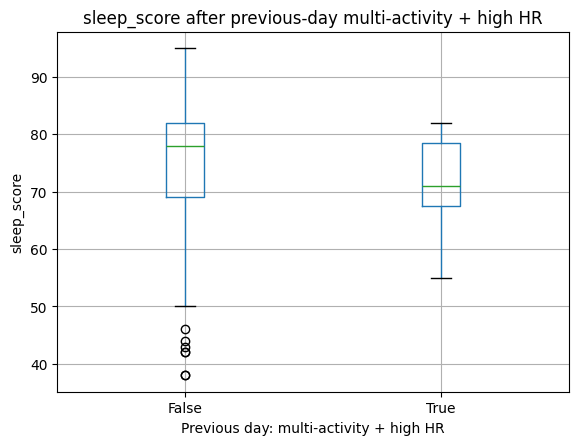

<Figure size 600x400 with 0 Axes>

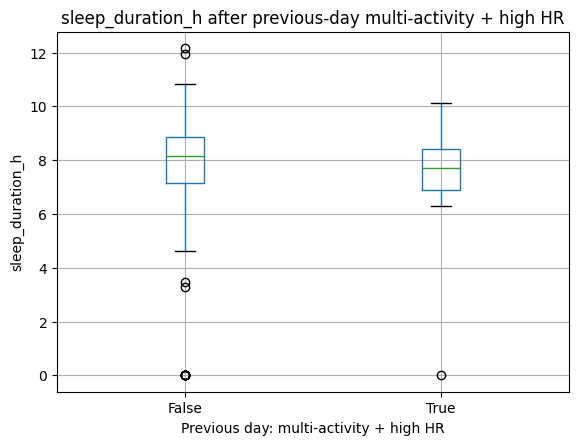

<Figure size 600x400 with 0 Axes>

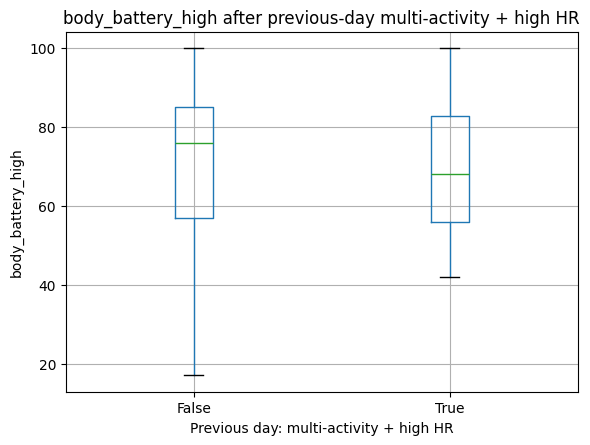

<Figure size 600x400 with 0 Axes>

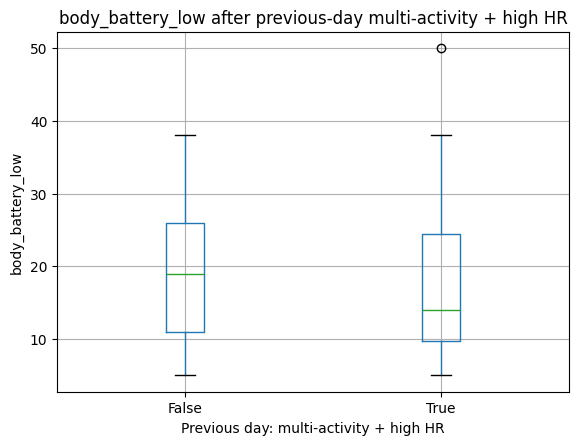

<Figure size 600x400 with 0 Axes>

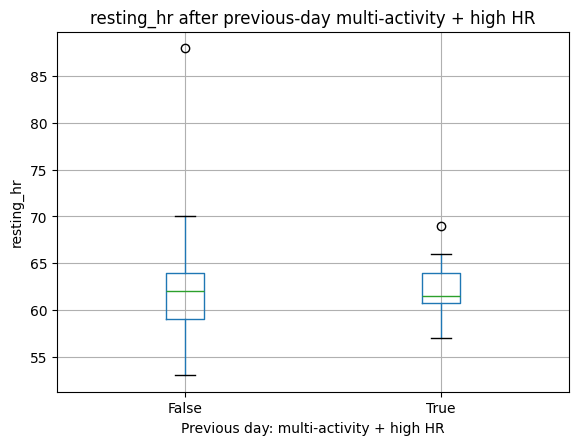

<Figure size 600x400 with 0 Axes>

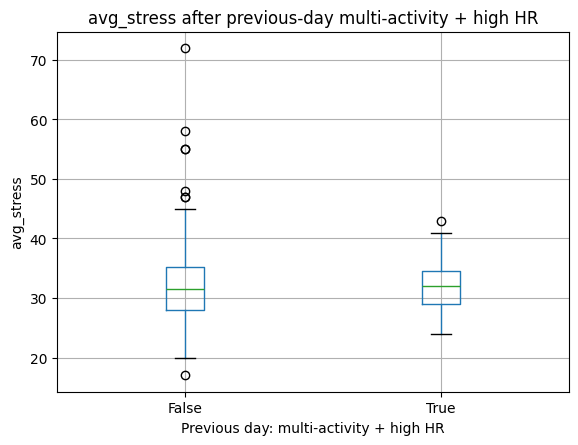

In [10]:
for metric in metrics_to_compare:
    if metric in df.columns:
        plt.figure(figsize=(6, 4))
        df.boxplot(column=metric, by=group_col)
        plt.title(f"{metric} after previous-day multi-activity + high HR")
        plt.suptitle("")
        plt.xlabel("Previous day: multi-activity + high HR")
        plt.ylabel(metric)
        plt.show()

In [11]:
def permutation_test_mean_difference(data, group_col, metric_col, n_permutations=5000, random_state=42):
    rng = np.random.default_rng(random_state)
    
    temp = data[[group_col, metric_col]].dropna().copy()
    
    observed_false = temp.loc[temp[group_col] == False, metric_col]
    observed_true = temp.loc[temp[group_col] == True, metric_col]
    
    observed_diff = observed_true.mean() - observed_false.mean()
    
    shuffled_diffs = []
    
    values = temp[metric_col].values
    groups = temp[group_col].values
    
    for _ in range(n_permutations):
        shuffled_groups = rng.permutation(groups)
        
        false_values = values[shuffled_groups == False]
        true_values = values[shuffled_groups == True]
        
        shuffled_diff = true_values.mean() - false_values.mean()
        shuffled_diffs.append(shuffled_diff)
    
    shuffled_diffs = np.array(shuffled_diffs)
    
    p_value = np.mean(np.abs(shuffled_diffs) >= np.abs(observed_diff))
    
    return observed_diff, p_value


perm_results = []

for metric in metrics_to_compare:
    if metric in df.columns:
        observed_diff, p_value = permutation_test_mean_difference(
            data=df,
            group_col=group_col,
            metric_col=metric,
            n_permutations=5000
        )
        
        perm_results.append({
            "metric": metric,
            "observed_difference_true_minus_false": observed_diff,
            "permutation_p_value": p_value
        })

perm_results = pd.DataFrame(perm_results)
display(perm_results)

,metric,observed_difference_true_minus_false,permutation_p_value
0,sleep_score,-2.965625,0.3892
1,sleep_duration_h,-0.339032,0.5980
2,body_battery_high,-3.200758,0.5206
3,body_battery_low,0.106061,0.9688
4,resting_hr,0.369318,0.7278
5,avg_stress,-0.066667,0.9858


On fait un permutation test.

L’idée est simple :
on garde les valeurs réelles, mais on mélange aléatoirement les labels True et False.

Si la différence observée dans les vraies données est beaucoup plus forte que les différences obtenues au hasard, le p-value sera faible.

Si le p-value est élevé, cela veut dire que la différence observée pourrait facilement venir du bruit.

Comme ton dataset est personnel et petit, ce test est plus prudent qu’une conclusion trop rapide.

In [12]:
target = "body_battery_high"

features = [
    "prev_day_activity_count",
    "prev_day_total_activity_duration_h",
    "prev_day_total_activity_distance_km",
    "prev_day_total_activity_calories",
    "prev_day_mean_activity_hr",
    "prev_day_max_activity_hr",
    "prev_day_max_aerobic_te",
    "prev_day_total_activity_steps",
    "prev_day_total_body_battery_drain_activity",
    "prev_day_multi_activity_day",
    "prev_day_high_activity_hr_day",
    "prev_day_multi_activity_high_hr_day"
]

features = [col for col in features if col in df.columns]

model_data = df[["date"] + features + [target]].dropna(subset=[target]).copy()

X = model_data[features]
y = model_data[target]

split_index = int(len(model_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

dates_test = model_data["date"].iloc[split_index:]

print("Features used:")
print(features)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)

Features used:
['prev_day_activity_count', 'prev_day_total_activity_duration_h', 'prev_day_total_activity_distance_km', 'prev_day_total_activity_calories', 'prev_day_mean_activity_hr', 'prev_day_max_activity_hr', 'prev_day_max_aerobic_te', 'prev_day_total_activity_steps', 'prev_day_total_body_battery_drain_activity', 'prev_day_multi_activity_day', 'prev_day_high_activity_hr_day', 'prev_day_multi_activity_high_hr_day']

Train size: (118, 12)
Test size: (30, 12)


On définit un problème de régression.

Objectif : prédire body_battery_high, donc le niveau maximal de Body Battery atteint le lendemain.

On utilise uniquement les variables d’activité de la veille.
Cela évite de tricher avec des variables du jour même qui seraient déjà très proches de la récupération.

In [13]:
baseline_pred = np.repeat(y_train.mean(), len(y_test))

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")

Baseline MAE: 20.98
Baseline RMSE: 24.71


La baseline prédit toujours la moyenne de Body Battery high.

Un modèle ML n’est intéressant que s’il fait mieux que cette baseline.
Si la Random Forest ne bat pas la baseline, cela veut dire que les variables d’activité seules ne suffisent pas à prédire correctement la récupération.

In [14]:
rf_bb_activity_only = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=3,
        random_state=42
    ))
])

rf_bb_activity_only.fit(X_train, y_train)

y_pred = rf_bb_activity_only.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Random Forest MAE: {mae:.2f}")
print(f"Random Forest RMSE: {rmse:.2f}")
print(f"Random Forest R2: {r2:.2f}")

Random Forest MAE: 18.81
Random Forest RMSE: 22.55
Random Forest R2: -0.54


Notes

On entraîne une Random Forest Regressor.

Ce modèle cherche des relations non linéaires entre les activités de la veille et la Body Battery du lendemain.

Exemple de relation possible :

une activité légère peut être neutre ou positive
une activité intense peut être associée à une récupération plus basse
l’effet peut dépendre de la durée, de la HR max ou de la charge aérobie

,feature,importance
7,prev_day_total_activity_steps,0.176424
1,prev_day_total_activity_duration_h,0.165384
3,prev_day_total_activity_calories,0.150374
0,prev_day_activity_count,0.120568
4,prev_day_mean_activity_hr,0.083770
6,prev_day_max_aerobic_te,0.077091
5,prev_day_max_activity_hr,0.070160
2,prev_day_total_activity_distance_km,0.064853
8,prev_day_total_body_battery_drain_activity,0.058628
9,prev_day_multi_activity_day,0.018443


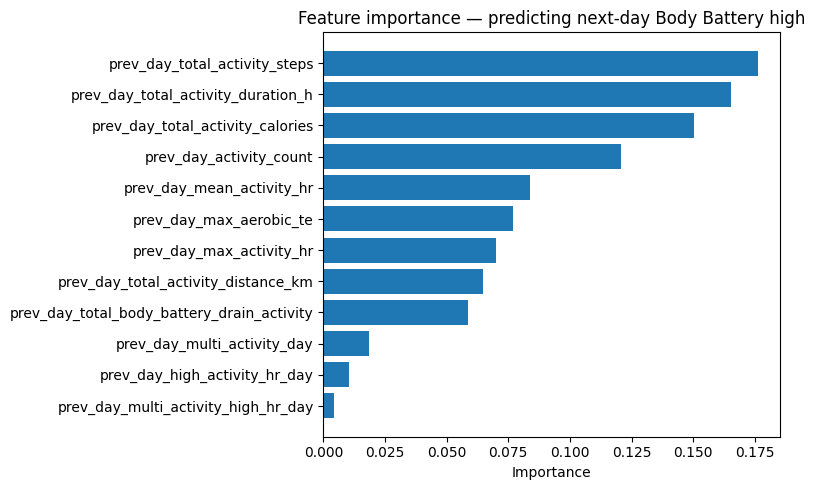

In [15]:
rf_model = rf_bb_activity_only.named_steps["model"]

importances = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importances)

plt.figure(figsize=(8, 5))
plt.barh(importances["feature"], importances["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Feature importance — predicting next-day Body Battery high")
plt.tight_layout()
plt.show()

On regarde quelles variables la Random Forest utilise le plus.

Si prev_day_max_activity_hr, prev_day_activity_count, prev_day_total_activity_duration_h ou prev_day_max_aerobic_te ressortent haut, cela suggère que la charge d’activité de la veille aide à expliquer la récupération du lendemain.

Attention : importance ne veut pas dire causalité.
Cela veut seulement dire que le modèle utilise cette variable pour améliorer ses prédictions.